# Augmentations

In [1]:
from pathlib import Path

root = Path.cwd()
print(root)
if root.name == "ipynb":
    root = root.parent
print(root)

import time
from typing import NamedTuple

import tifffile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.ndimage import rotate



/scratch/wmz2007/neuroinfo_fruitfly/ipynb
/scratch/wmz2007/neuroinfo_fruitfly


In [2]:
path = root / "fisbe/biapy-debug/train/raw/R38F04-20181005_63_G3.tif"
img = tifffile.imread(path)
img = np.moveaxis(img, 0, 1)  # BiaPy ZCYX -> CZYX
print(path)
print(img.shape, img.dtype)

/scratch/wmz2007/neuroinfo_fruitfly/fisbe/biapy-debug/train/raw/R38F04-20181005_63_G3.tif
(3, 431, 687, 684) uint16


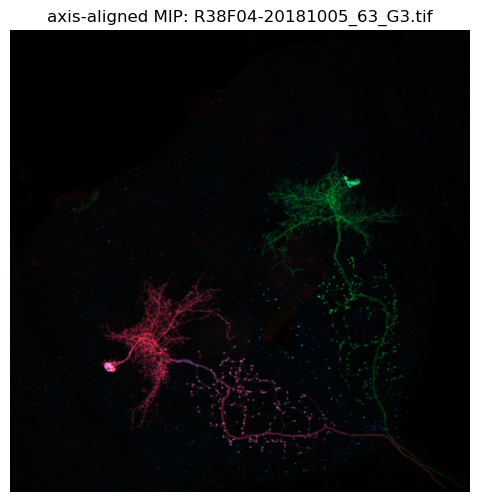

In [3]:
def gen_mip(raw, axis) -> np.ndarray:
    """Max-intensity projection of RGB channels. For CZYX: axis=1 is the z projection."""
    mip = raw.astype(np.float32).max(axis=axis)
    mip = (mip - mip.min()) / (np.ptp(mip) + 1e-8)
    return np.moveaxis(mip, 0, -1)  # (Y, X, C)


plt.figure(figsize=(6, 6))
plt.imshow(gen_mip(img, 1))
plt.axis("off")
plt.title(f"axis-aligned MIP: {path.name}")
plt.show()

In [4]:
# Rotating the full volume with scipy costs ~0.6-20 s per update, far too slow to drag a
# slider. The volume is ~99% background, so instead we keep only the bright voxels and
# scatter them onto the canvas with a per-pixel max -- that is the same MIP, in ~30 ms.


class Cloud(NamedTuple):
    pts: np.ndarray  # (N, 3) float32, ZYX, centred on the volume
    vals: np.ndarray  # (N, C) float32
    size: int  # canvas edge, in pixels
    radius: float
    hi: np.ndarray  # (C,) display white point


def block_max(vol, factor):
    """Downsample by max-pooling, so thin bright neurites survive."""
    if factor == 1:
        return vol
    c = vol.shape[0]
    z, y, x = ((d // factor) * factor for d in vol.shape[1:])
    v = vol[:, :z, :y, :x]
    return v.reshape(c, z // factor, factor, y // factor, factor, x // factor, factor).max(axis=(2, 4, 6))


def build_cloud(vol, downsample=2, percentile=98.0, z_scale=1.0) -> Cloud:
    """Bright voxels of a CZYX volume as a centred point cloud.

    `percentile` sets how much of the volume is kept (98 -> brightest 2%); lower it to
    pick up dim neurites, raise it for a faster viewer. `z_scale` corrects anisotropic
    voxels, so that a rotation out of the xy plane keeps the right proportions.
    """
    v = block_max(vol, downsample)
    lum = v.max(axis=0)
    thr = np.percentile(lum[::4, ::4, ::4], percentile)
    zz, yy, xx = np.nonzero(lum > thr)

    pts = np.stack([zz, yy, xx], axis=1).astype(np.float32)
    pts -= (np.asarray(lum.shape, dtype=np.float32) - 1) / 2
    pts[:, 0] *= z_scale
    vals = v[:, zz, yy, xx].T.astype(np.float32)

    # A canvas sized to the farthest point keeps every angle in frame at a fixed scale.
    radius = float(np.ceil(np.linalg.norm(pts, axis=1).max()))
    hi = np.maximum(np.percentile(vals, 99.9, axis=0).astype(np.float32), 1.0)
    return Cloud(pts, vals, int(2 * radius + 1), radius, hi)


def rotation_matrix(azim, elev, roll) -> np.ndarray:
    """Rotation in ZYX index space: azim about y, elev about x, roll about the view axis."""
    a, e, r = np.deg2rad([azim, elev, roll])
    ca, sa, ce, se, cr, sr = np.cos(a), np.sin(a), np.cos(e), np.sin(e), np.cos(r), np.sin(r)
    ry = np.array([[ca, 0, -sa], [0, 1, 0], [sa, 0, ca]])
    rx = np.array([[ce, -se, 0], [se, ce, 0], [0, 0, 1]])
    rz = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]])
    return (rz @ rx @ ry).astype(np.float32)


def rotated_mip(cloud: Cloud, azim=0.0, elev=0.0, roll=0.0) -> np.ndarray:
    """Rotate the cloud, then project along z by taking a max per output pixel."""
    p = cloud.pts @ rotation_matrix(azim, elev, roll).T
    n = cloud.size
    yi = np.clip(np.rint(p[:, 1] + cloud.radius), 0, n - 1).astype(np.int64)
    xi = np.clip(np.rint(p[:, 2] + cloud.radius), 0, n - 1).astype(np.int64)
    out = np.zeros((n * n, cloud.vals.shape[1]), np.float32)
    np.maximum.at(out, yi * n + xi, cloud.vals)
    return out.reshape(n, n, -1)


def mip_to_rgb(mip, hi, gamma=1.0) -> np.ndarray:
    """Fixed white point, so brightness does not flicker between angles. gamma < 1 lifts dim signal."""
    return np.clip(mip / hi, 0.0, 1.0) ** gamma

In [5]:
t = time.perf_counter()
cloud = build_cloud(img, downsample=2, percentile=98.0, z_scale=1.0)
print(f"built in {time.perf_counter() - t:.1f}s: {len(cloud.pts) / 1e3:.0f}k points, {cloud.size}px canvas")

t = time.perf_counter()
rotated_mip(cloud, azim=30, elev=20)
print(f"{(time.perf_counter() - t) * 1000:.0f} ms per rotated MIP")

built in 5.7s: 501k points, 505px canvas
36 ms per rotated MIP


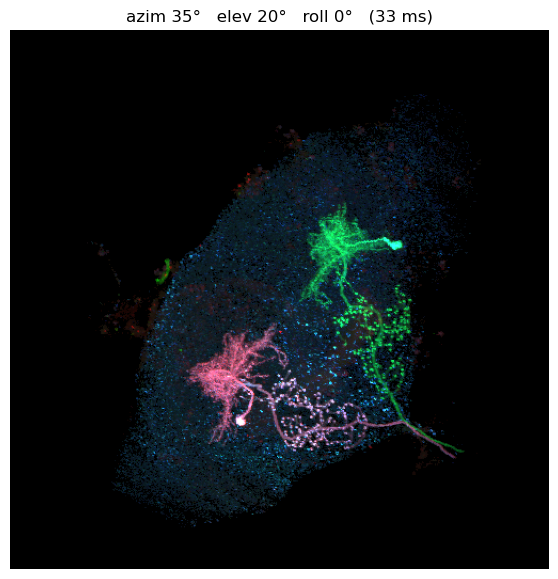

In [6]:
def show_mip(azim=0.0, elev=0.0, roll=0.0, gamma=0.7):
    t = time.perf_counter()
    rgb = mip_to_rgb(rotated_mip(cloud, azim, elev, roll), cloud.hi, gamma)
    dt = (time.perf_counter() - t) * 1000
    plt.figure(figsize=(7, 7))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(f"azim {azim:.0f}°   elev {elev:.0f}°   roll {roll:.0f}°   ({dt:.0f} ms)")
    plt.show()


show_mip(azim=35, elev=20)

In [7]:
def _angle(name, value=0.0):
    return widgets.FloatSlider(
        value=value, min=-180, max=180, step=5, description=name, continuous_update=False
    )


widgets.interact(
    show_mip,
    azim=_angle("azim"),
    elev=_angle("elev"),
    roll=_angle("roll"),
    gamma=widgets.FloatSlider(value=0.7, min=0.2, max=1.5, step=0.05, description="gamma", continuous_update=False),
);

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='azim', max=180.0, min=-180.…

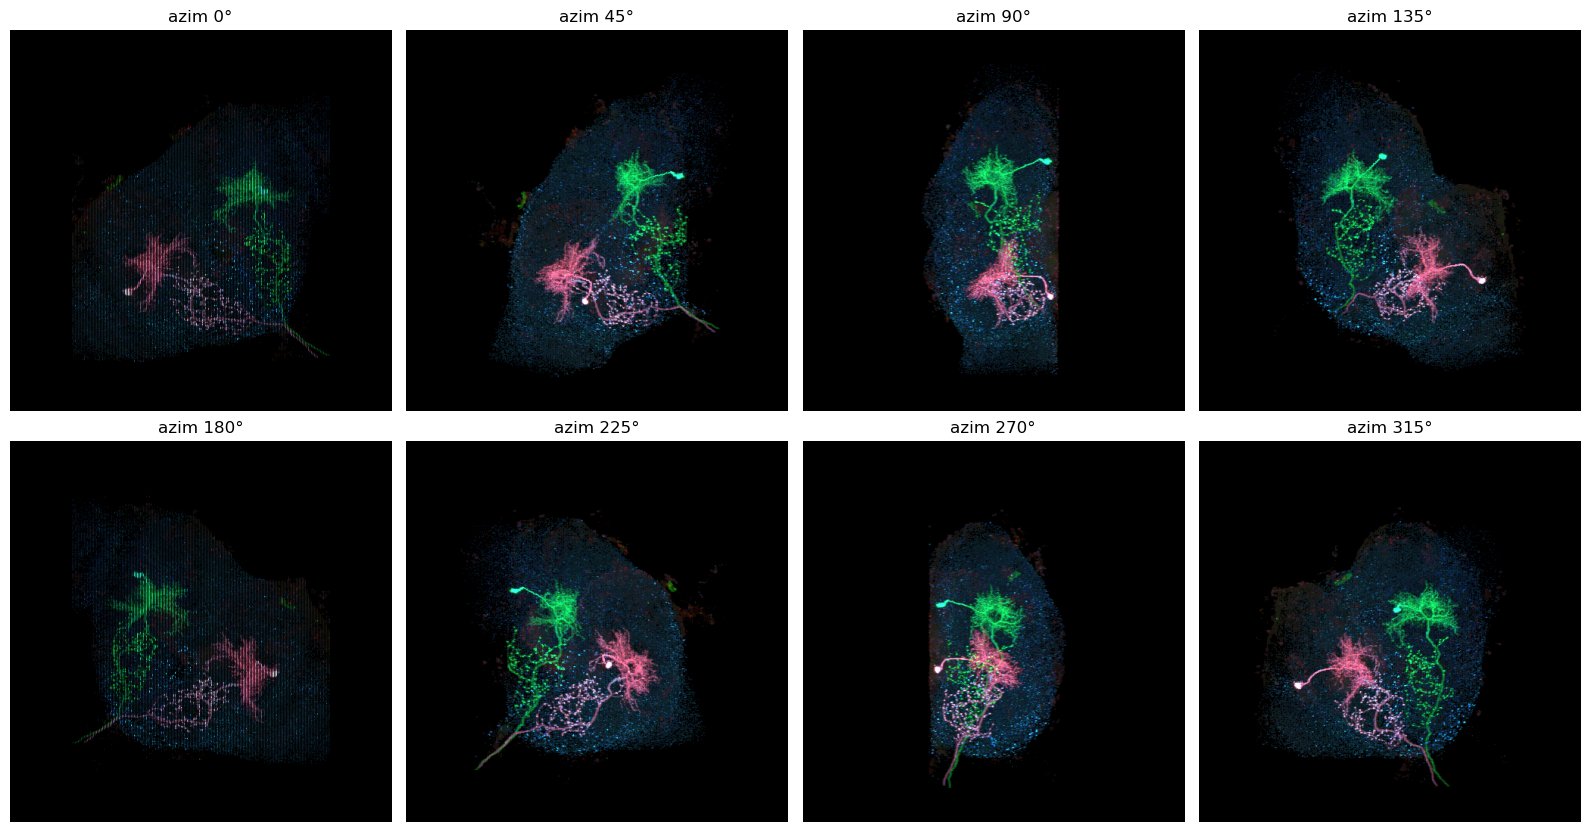

In [8]:
# Turntable: a static fallback if the sliders do not render in this frontend.
angles = range(0, 360, 45)
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, azim in zip(axes.ravel(), angles):
    ax.imshow(mip_to_rgb(rotated_mip(cloud, azim=azim, elev=15), cloud.hi, gamma=0.7))
    ax.set_title(f"azim {azim}°")
    ax.axis("off")
plt.tight_layout()
plt.show()